In [21]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

In [22]:
filename = "SBE-ketqua-SBE_thamso_chi_delta0_30_deltat_25_longtime_Absorption-N-P.txt"

t, time_Re_P, time_Im_P, time_E_laser = np.loadtxt(filename, comments="#", unpack=True, usecols=(0,3,4,6))

/tmp/ipykernel_22509/4134013467.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


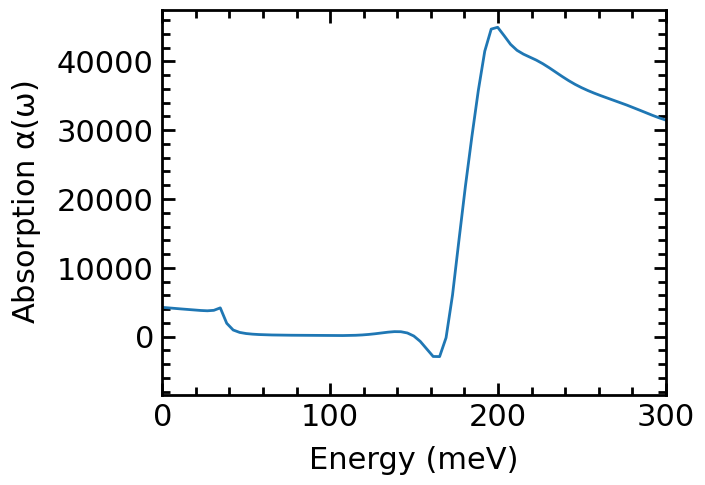

In [23]:
### FFT tu mien thoi gian qua mien nang luong

P_t = time_Re_P + 1j * time_Im_P
E_t = time_E_laser

dt = t[1] - t[0]
N_points = len(t)
hbar = 658.5

P_omega = np.fft.fftshift(np.fft.fft(P_t))
E_omega = np.fft.fftshift(np.fft.fft(E_t))

freq = np.fft.fftshift(np.fft.fftfreq(N_points, d=dt))
omega = 2 * np.pi * freq
energy = hbar * omega
with np.errstate(divide='ignore', invalid='ignore'):
    alpha = np.imag(P_omega / E_omega)

fig, ax = plt.subplots()

ax.plot(energy, alpha)

ax.set_xlim(0, 300) 

ax.set_xlabel('Energy (meV)')
ax.set_ylabel(r'Absorption $\alpha(\omega)$')
ax.legend()

plt.show()